In [15]:
import pandas as pd
import matplotlib.pyplot as plt


# Data Loading


In [38]:
cohort_df = pd.read_csv("/content/05_cohort.csv")
mrr_df = pd.read_csv("/content/03_MRR.csv")
arpu_df = pd.read_csv("/content/06_ARPU.csv")
ltv_df = pd.read_csv("/content/07_ltv.csv")
revenue_conc_df = pd.read_csv("/content/08_revenue_conc.csv")

##Cohort Analysis (Heatmap)

In [17]:
cohort_df.head(5)

,cohort_month,months_since_cohort,active_customers,cohort_size,retention_rate
0,2011-01-01 00:00:00,0,362,362,1.0
1,2011-01-01 00:00:00,1,362,362,1.0
2,2011-01-01 00:00:00,2,362,362,1.0
3,2011-01-01 00:00:00,3,362,362,1.0
4,2011-01-01 00:00:00,4,362,362,1.0


In [18]:
cohort_pivot = cohort_df.pivot(
    index="cohort_month",
    columns="months_since_cohort",
    values="retention_rate"
)
cohort_pivot.head()

months_since_cohort,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
cohort_month,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2011-02-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
2011-03-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
2011-04-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
2011-05-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN


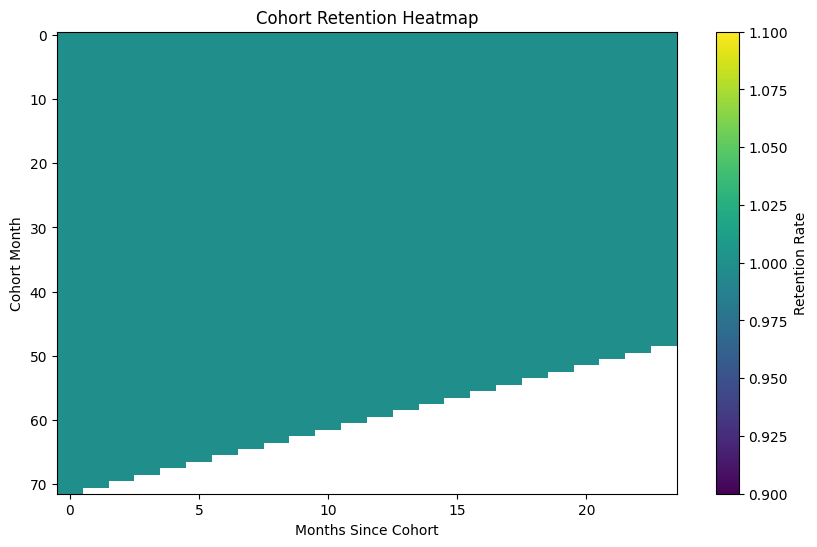

In [19]:
cohort_pivot = cohort_pivot.iloc[:, :24]  # limit width

plt.figure(figsize=(10,6))

plt.imshow(cohort_pivot, aspect='auto')

plt.colorbar(label='Retention Rate')

plt.xlabel("Months Since Cohort")
plt.ylabel("Cohort Month")
plt.title("Cohort Retention Heatmap")

plt.show()

## MRR Analysis

In [23]:
mrr_df.head()

,active_month,active_customers,mrr
0,2011-01-01 00:00:00,362,29211.90
1,2011-02-01 00:00:00,532,41746.95
2,2011-03-01 00:00:00,651,50836.05
3,2011-04-01 00:00:00,746,57564.25
4,2011-05-01 00:00:00,846,64896.35


In [26]:
mrr_df["active_month"] = pd.to_datetime(mrr_df["active_month"])

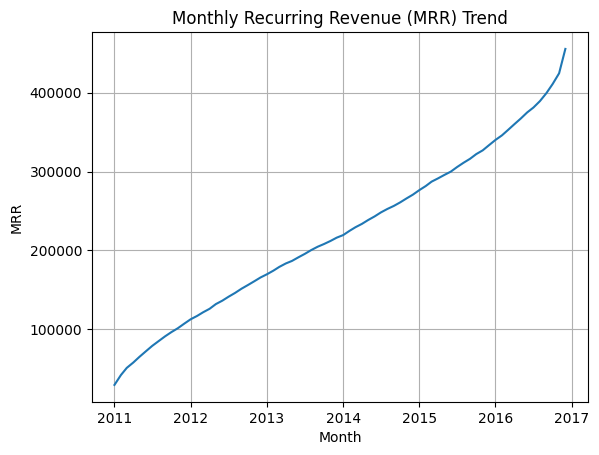

In [27]:
plt.figure()

plt.plot(mrr_df["active_month"], mrr_df["mrr"])

plt.xlabel("Month")
plt.ylabel("MRR")
plt.title("Monthly Recurring Revenue (MRR) Trend")

plt.grid()

plt.show()

# MRR increases over time as more customers become active,
# then stabilizes near the snapshot boundary.

## ARPU Analysis

In [25]:
arpu_df.head()

,active_month,active_customers,mrr,arpu
0,2011-01-01 00:00:00,362,29211.90,80.70
1,2011-02-01 00:00:00,532,41746.95,78.47
2,2011-03-01 00:00:00,651,50836.05,78.09
3,2011-04-01 00:00:00,746,57564.25,77.16
4,2011-05-01 00:00:00,846,64896.35,76.71


In [28]:
arpu_df["active_month"] = pd.to_datetime(arpu_df["active_month"])

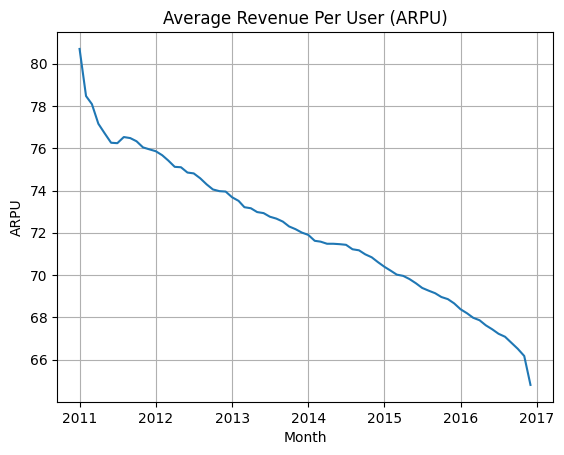

In [29]:
plt.figure()

plt.plot(arpu_df["active_month"], arpu_df["arpu"])

plt.xlabel("Month")
plt.ylabel("ARPU")
plt.title("Average Revenue Per User (ARPU)")

plt.grid()

plt.show()

# ARPU shows a gradual decline over time, suggesting a shift
# toward lower-paying customers or increased acquisition of lower-tier plans.

##Combined ARPU & MRR

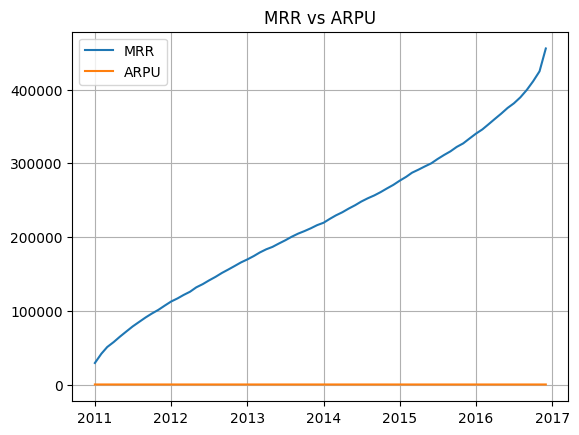

In [30]:
plt.figure()

plt.plot(mrr_df["active_month"], mrr_df["mrr"], label="MRR")
plt.plot(arpu_df["active_month"], arpu_df["arpu"], label="ARPU")

plt.legend()
plt.title("MRR vs ARPU")

plt.grid()

plt.show()

# MRR increases steadily over time, driven by customer growth, while ARPU
# declines, indicating that revenue expansion is primarily volume-driven
# rather than pricing-driven.

## LTV Analysis

In [33]:
ltv_df.head()

,customerid,tenure,monthlycharges,ltv
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1936.30
2,3668-QPYBK,2,53.85,107.70
3,7795-CFOCW,45,42.30,1903.50
4,9237-HQITU,2,70.70,141.40


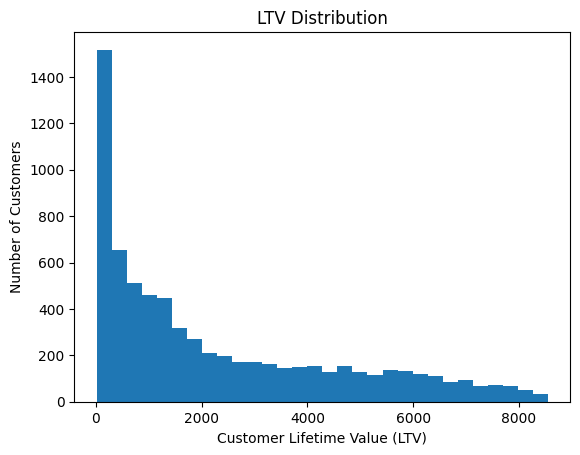

In [37]:
plt.figure()

plt.hist(ltv_df["ltv"], bins=30)

plt.xlabel("Customer Lifetime Value (LTV)")
plt.ylabel("Number of Customers")
plt.title("LTV Distribution")

plt.show()

# The LTV distribution is right-skewed, indicating that most
# customers generate relatively low revenue, while a small group
# of high-value customers contributes disproportionately.

#Revenue Concenteration Analysis

In [39]:
revenue_conc_df.head()

,decile,customers,revenue,revenue_share,cumulative_revenue_share
0,1,704,4936328.75,0.31,0.31
1,2,704,3671016.80,0.23,0.54
2,3,703,2661963.05,0.17,0.70
3,4,703,1811298.40,0.11,0.81
4,5,703,1189752.40,0.07,0.89


In [45]:
revenue_conc_df = revenue_conc_df.sort_values("decile")

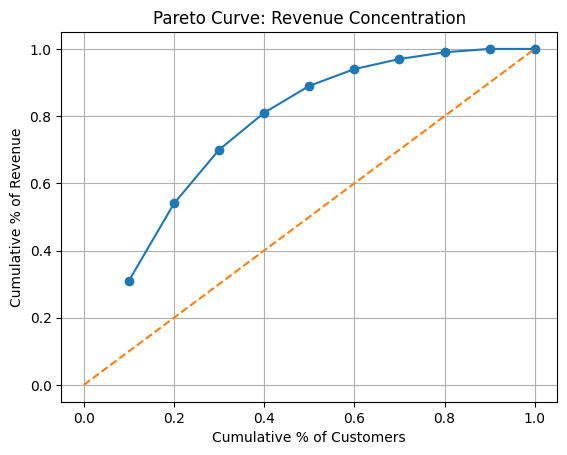

In [46]:
revenue_conc_df["cumulative_customers"] = revenue_conc_df["decile"] / 10

plt.figure()

plt.plot(revenue_conc_df["cumulative_customers"], revenue_conc_df["cumulative_revenue_share"], marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.title("Pareto Curve: Revenue Concentration")

plt.grid()

plt.show()